# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [3]:
# Load the main Python packages used throughout the notebook
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

In [4]:
# Read the COMPAS dataset directly from the online source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape[0]

7214

In [5]:
# Preview the first 10 observations from the original data
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [6]:
# Prepare the dataset by selecting variables, filtering rows, and defining model inputs
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[
    [
        "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
        "priors_count", "days_b_screening_arrest", "decile_score",
        "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
    ]
].copy()

# Apply the same filters used in the lecture workflow
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"].copy()

# Convert jail date columns to datetime
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

# Build categorical variables for the regression model
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["Less than 25", "25 - 45", "Greater than 45"]
)
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["African-American", "Asian", "Caucasian", "Hispanic", "Native American", "Other"]
)
df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Female", "Male"]
)
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"]
)

# Create a binary outcome for the logistic regression
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

df.shape[0]

6172

In [7]:
# Show the first rows of the clean dataset
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,score_binary
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore,1


In [8]:
# Show variable types and missing-value counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   object             
 2   race                     6172 non-null   object             
 3   age_cat                  6172 non-null   object             
 4   score_text               6172 non-null   object             
 5   sex                      6172 non-null   object             
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   int64              
 10  two_year_recid           6172 non-null   int64              
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [9]:
# Calculate jail stay length in days and compare it with decile score
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
float(df["length_of_stay"].corr(df["decile_score"]))

0.20747808478031807

After filtering we have the following demographic breakdown:

In [10]:
# Count observations in each age group
df["age_cat"].value_counts(dropna=False)

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [11]:
# Count observations in each race category
df["race"].value_counts(dropna=False)

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [12]:
# Check the percentage distribution across major race groups
race_pct = df["race"].value_counts(normalize=True).mul(100)

print("Black defendants: %.2f%%" % race_pct.get("African-American", 0))
print("White defendants: %.2f%%" % race_pct.get("Caucasian", 0))
print("Hispanic defendants: %.2f%%" % race_pct.get("Hispanic", 0))
print("Asian defendants: %.2f%%" % race_pct.get("Asian", 0))
print("Native American defendants: %.2f%%" % race_pct.get("Native American", 0))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [13]:
# Summarize the COMPAS risk labels in the dataset
df["score_text"].value_counts(dropna=False)

,count
score_text,
Low,3421
Medium,1607
High,1144


In [14]:
# Tabulate sex against race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [15]:
# Count observations by sex
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


In [16]:
# Display the gender composition of the sample in percentages
sex_pct = df["sex"].value_counts(normalize=True).mul(100)

print("Men: %.2f%%" % sex_pct.get("Male", 0))
print("Women: %.2f%%" % sex_pct.get("Female", 0))

Men: 80.96%
Women: 19.04%


In [17]:
# Count defendants who recidivated within the two-year window
float((df["two_year_recid"] == 1).sum())

2809.0

In [18]:
# Compute the share of defendants who recidivated within two years
float((df["two_year_recid"] == 1).mean() * 100)

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

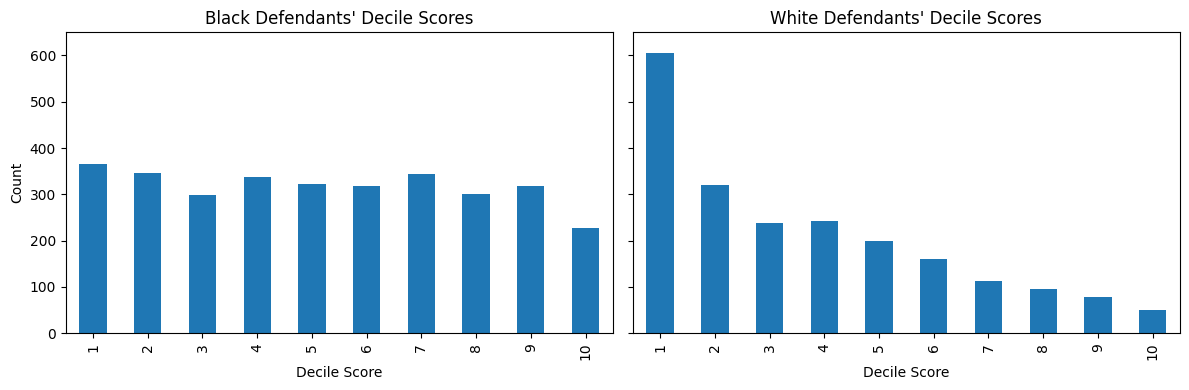

In [19]:
# Compare decile score frequencies for Black and White defendants
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

black_counts = df.loc[df["race"] == "African-American", "decile_score"].value_counts().sort_index()
white_counts = df.loc[df["race"] == "Caucasian", "decile_score"].value_counts().sort_index()

black_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Black Defendants' Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

white_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("White Defendants' Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [20]:
# Cross-classify decile scores by race
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [21]:
# Estimate the logistic regression used in the lecture analysis
model_glm = smf.logit(
    "score_binary ~ C(gender_factor, Treatment(reference='Male')) + "
    "C(age_factor, Treatment(reference='25 - 45')) + "
    "C(race_factor, Treatment(reference='Caucasian')) + "
    "priors_count + C(crime_factor) + two_year_recid",
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        14:56:22   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

### Interpreting the Logistic Regression Output

This model evaluates whether race is still associated with receiving a higher COMPAS classification after accounting for gender, age category, prior offenses, charge degree, and two-year recidivism. In other words, it checks whether differences remain after holding several relevant factors constant.

If the coefficient on `race_factor[T.African-American]` is positive, the model suggests that Black defendants have higher odds of being placed in the high-score category relative to the Caucasian reference group, conditional on the other controls. Small numerical differences from the R version are acceptable because Python and R may handle categorical coding and estimation details somewhat differently.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [22]:
# Derive the adjusted Black-versus-White probability effect from the model
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))
beta_black = model_glm.params["C(race_factor, Treatment(reference='Caucasian'))[T.African-American]"]
float(np.exp(beta_black) / (1 - control + (control * np.exp(beta_black))))

1.452837413382345

Women are 19.4% more likely than men to get a higher score.

In [23]:
# Derive the adjusted Female-versus-Male probability effect from the model
beta_female = model_glm.params["C(gender_factor, Treatment(reference='Male'))[T.Female]"]
float(np.exp(beta_female) / (1 - control + (control * np.exp(beta_female))))

1.1947946538834509

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [24]:
# Derive the adjusted effect for defendants under 25 compared with ages 25-45
beta_under25 = model_glm.params["C(age_factor, Treatment(reference='25 - 45'))[T.Less than 25]"]
float(np.exp(beta_under25) / (1 - control + (control * np.exp(beta_under25))))

2.496119530753956

In [25]:
# Produce fitted probabilities and convert them into predicted classes
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [26]:
# Construct the overall confusion matrix and summarize model performance
print("Overall Confusion Matrix")

overall_cm = pd.crosstab(
    pd.Series(df["pred_class"], name="Predicted"),
    pd.Series(df["two_year_recid"], name="Actual")
)

display(overall_cm)

TP = overall_cm.loc["Recid", 1] if ("Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
TN = overall_cm.loc["No Recid", 0] if ("No Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FP = overall_cm.loc["Recid", 0] if ("Recid" in overall_cm.index and 0 in overall_cm.columns) else 0
FN = overall_cm.loc["No Recid", 1] if ("No Recid" in overall_cm.index and 1 in overall_cm.columns) else 0
n = overall_cm.to_numpy().sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

Overall Confusion Matrix


Actual,0,1
Predicted,,
No Recid,2653,945
Recid,710,1864



Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [27]:
# Compute confusion matrix statistics separately for each racial group
print("Confusion Matrix by Race")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"] = (temp["pred_class"] == "Recid").astype(int)

race_metrics = (
    temp.groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum()
    }))
    .reset_index()
)

race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False)

display(race_metrics)

Confusion Matrix by Race


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
0,African-American,3175,1373,959,555,288,0.734,0.712,0.827,0.367,0.173
2,Caucasian,2103,381,1148,133,441,0.727,0.741,0.464,0.104,0.536
3,Hispanic,509,81,306,14,108,0.760,0.853,0.429,0.044,0.571
5,Other,343,22,216,3,102,0.694,0.880,0.177,0.014,0.823
1,Asian,31,2,22,1,6,0.774,0.667,0.250,0.043,0.750
4,Native American,11,5,2,4,0,0.636,0.556,1.000,0.667,0.000


In [28]:
# Measure FPR and FNR gaps relative to the Caucasian reference group
print("FPR and FNR Disparity by Race")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

white_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].iloc[0]
white_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].iloc[0]

disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

display(disparity)

FPR and FNR Disparity by Race


,race,n,FPR,FNR,delta_FPR,delta_FNR
0,African-American,3175,0.367,0.173,0.263,-0.363
2,Caucasian,2103,0.104,0.536,0.000,0.000
3,Hispanic,509,0.044,0.571,-0.060,0.035
5,Other,343,0.014,0.823,-0.090,0.287
1,Asian,31,0.043,0.750,-0.061,0.214
4,Native American,11,0.667,0.000,0.563,-0.536


### Interpreting the Error-Rate Disparities

This table focuses on whether the model’s mistakes are distributed evenly across race groups. Rather than looking only at average performance, it examines whether some groups face systematically higher false positive rates or false negative rates than others.

A positive `delta_FPR` indicates that a group experiences more false positives than the Caucasian reference group, while a positive `delta_FNR` indicates more false negatives. These comparisons matter because a model can look acceptable overall and still impose unequal error patterns across different groups.

#Assignment 2

In [29]:
# # Install the explanation libraries if they are not already available
%pip install lime shap dice-ml

In [34]:
# Set up the target, predictors, and numeric versions of the jail date fields
import numpy as np
import pandas as pd

target = "two_year_recid"

df_explain = df.copy()

for col in ["c_jail_in", "c_jail_out"]:
    dt = pd.to_datetime(df_explain[col], errors="coerce")
    df_explain[f"{col}_num"] = dt.map(lambda x: x.timestamp() if pd.notnull(x) else np.nan)

for col in ["c_jail_in_num", "c_jail_out_num"]:
    df_explain[col] = df_explain[col].fillna(df_explain[col].median())

numeric_features = [
    "age",
    "priors_count",
    "decile_score",
    "days_b_screening_arrest",
    "is_recid",
    "c_jail_in_num",
    "c_jail_out_num",
]

category_features = [
    "age_cat",
    "sex",
    "race",
    "c_charge_degree",
    "score_text",
]

features = numeric_features + category_features

X = df_explain[features].copy()
y = df_explain[target].astype(int)

In [35]:
# Create the training and test samples from the cleaned COMPAS dataset

# Split the cleaned COMPAS data into training and test sets
from sklearn.model_selection import train_test_split

# X and y from the cleaned COMPAS cohort (Lecture 01)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 12), Test: (1235, 12)


In [36]:
# Fit logistic regression and gradient-boosted tree

# Define the transformations for numeric and categorical variables
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", ohe, category_features),
])

In [39]:
# Train the logistic regression pipeline as the interpretable baseline model
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'decile_score',
                                                   'days_b_screening_arrest',
                                                   'is_recid', 'c_jail_in_num',
                                                   'c_jail_out_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [38]:
# Train the gradient-boosted tree pipeline as the main black-box model
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'decile_score',
                                                   'days_b_screening_arrest',
                                                   'is_recid', 'c_jail_in_num',
                                                   'c_jail_out_num']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [40]:
# Evaluate model performance separately across racial groups

# Define a helper function to summarize race-specific classification metrics
import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix,
                             accuracy_score,
                             roc_auc_score)

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        auc = roc_auc_score(gdf["actual"], gdf["pred_prob"]) if gdf["actual"].nunique() > 1 else np.nan

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(
                gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else np.nan,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else np.nan,
            "AUC": round(auc, 3) if pd.notnull(auc) else np.nan,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR  FNR    AUC
0  African-American  641     0.977  0.049  0.0  0.991
2         Caucasian  427     0.972  0.045  0.0  0.994
3          Hispanic   94     0.968  0.061  0.0  0.974
5             Other   65     0.985  0.021  0.0  1.000
1             Asian    7     1.000  0.000  0.0  1.000
4   Native American    1     1.000  0.000  NaN    NaN

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.973  0.049  0.006  0.992
2         Caucasian  427     0.972  0.045  0.000  0.990
3          Hispanic   94     0.957  0.061  0.022  0.970
5             Other   65     0.985  0.021  0.000  0.999
1             Asian    7     1.000  0.000  0.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN


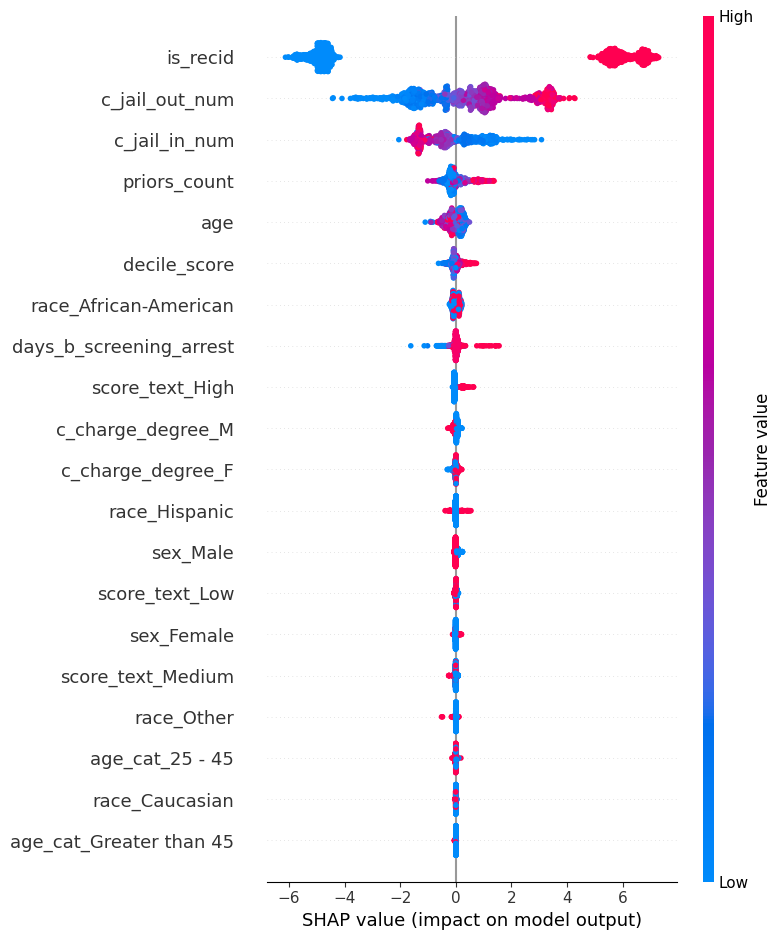

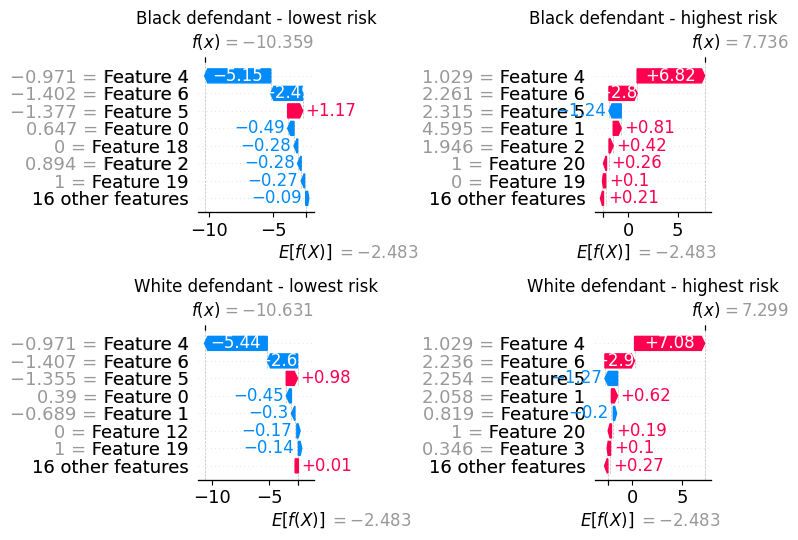

In [41]:
# Generate SHAP beeswarm and waterfall plots for the selected high- and low-risk defendants

import shap
import matplotlib.pyplot as plt

fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]

X_test_enc = fitted_preprocessor.transform(X_test)
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

feat_names = (numeric_features +
list(fitted_preprocessor
.named_transformers_["cat"]
.get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc,
                  feature_names=feat_names)

# Select highest-risk and lowest-risk defendant in each racial group
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_candidates = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

selected_cases = [
    ("Black defendant - lowest risk", black_candidates.index[0]),
    ("Black defendant - highest risk", black_candidates.index[-1]),
    ("White defendant - lowest risk", white_candidates.index[0]),
    ("White defendant - highest risk", white_candidates.index[-1]),
]

# Waterfall: highest-risk and lowest-risk defendant in each racial group
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (label, idx) in zip(axes.flatten(), selected_cases):
    loc = X_test.index.get_loc(idx)
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc],
                        max_display=8,
                        show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

## Part 1

The SHAP results indicate that the model is influenced mainly by **is_recid**, followed by **c_jail_out_num**, **c_jail_in_num**, **priors_count**, **age**, and **decile_score**. In the waterfall plots, the lower-risk defendants are pushed toward **No Recid** largely because **is_recid = 0**, while the higher-risk defendants are pushed toward **Recid** mainly because **is_recid = 1**. Overall, the model appears to depend more on these risk-related variables than on race directly.



In [42]:
# Produce LIME explanations for the same high- and low-risk defendants used in SHAP

from lime.lime_tabular import LimeTabularExplainer

fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)

lime_feature_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(category_features)
)

explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_enc),
    feature_names=lime_feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# Select the highest-risk and lowest-risk defendants in each racial group
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = X_test_copy[
    X_test_copy["race"] == "African-American"
].sort_values("pred_prob")

white_candidates = X_test_copy[
    X_test_copy["race"] == "Caucasian"
].sort_values("pred_prob")

black_low_idx = black_candidates.index[0]
black_high_idx = black_candidates.index[-1]
white_low_idx = white_candidates.index[0]
white_high_idx = white_candidates.index[-1]

selected_cases = [
    ("Black defendant - lowest risk", black_low_idx),
    ("Black defendant - highest risk", black_high_idx),
    ("White defendant - lowest risk", white_low_idx),
    ("White defendant - highest risk", white_high_idx),
]

# Generate and print the LIME explanations for the four selected defendants
for label, idx in selected_cases:
    row_enc = np.asarray(fitted_preprocessor.transform(X_test.loc[[idx]]))

    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=gbt_pipeline.named_steps["classifier"].predict_proba,
        num_features=6,
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {X_test_prob[X_test.index.get_loc(idx)]:.3f}")

    for feat, weight in exp.as_list():
        print(f"{feat:<45} {weight:+.4f}")


LIME: Black defendant - lowest risk
Predicted probability: 0.000
is_recid <= -0.97                             -0.7460
c_jail_out_num <= -0.89                       -0.2233
c_jail_in_num <= -0.90                        +0.1052
days_b_screening_arrest > 0.15                +0.0810
0.00 < race_African-American <= 1.00          -0.0221
score_text_High <= 0.00                       -0.0199

LIME: Black defendant - highest risk
Predicted probability: 1.000
-0.97 < is_recid <= 1.03                      +0.7308
c_jail_out_num > 0.63                         +0.1722
c_jail_in_num > 0.67                          -0.1420
days_b_screening_arrest <= 0.15               -0.0891
0.00 < race_African-American <= 1.00          -0.0236
sex_Female > 0.00                             +0.0232

LIME: White defendant - lowest risk
Predicted probability: 0.000
is_recid <= -0.97                             -0.7349
c_jail_out_num <= -0.89                       -0.2195
c_jail_in_num <= -0.90                       

## Part 2

LIME and SHAP are broadly consistent on the main predictors. Both methods identify **is_recid** as the strongest driver, with the jail-related variables also contributing substantially. For the low-risk individuals, both explanations support **No Recid**, and for the high-risk individuals, both support **Recid**. Their differences appear mostly among the smaller features, so the most reliable conclusions come from the variables that both methods rank highly.

In [43]:
# Use DiCE to generate counterfactual examples for the selected defendants

import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
y_train_named = y_train.rename(target)

dice_data = dice_ml.Data(
    dataframe = pd.concat([X_train, y_train_named], axis=1),
    continuous_features = numeric_features,
    outcome_name = target
)

dice_model = dice_ml.Model(
    model = gbt_pipeline,
    backend = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in selected_cases:

    query = X_test.loc[[idx]][features]

    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs = 1,
            desired_class = "opposite",
            permitted_range = {"age" : [18, 70],
                               "priors_count": [0, 38]},
            features_to_vary = "all"
        )

        print(f"\n DiCE counterfactuals: {label} ")
        cf.visualize_as_dataframe(show_only_changes=True)
        print("Immutable features race and sex were not allowed to vary.")

    except Exception as e:
        print(f"\n DiCE counterfactuals: {label} ")
        print("No counterfactuals found with the random method for this defendant.")

100%|██████████| 1/1 [00:00<00:00,  8.17it/s]


 DiCE counterfactuals: Black defendant - lowest risk 
Query instance (original outcome : 0)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,42,0,7,0.0,0,1.357114e+09,1.357700e+09,25 - 45,Male,African-American,M,Medium,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,-,34,-,-,1,-,-,-,-,-,-,-,1


...


 DiCE counterfactuals: White defendant - highest risk 
Query instance (original outcome : 1)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,44,13,9,0.0,1,1.416660e+09,1.418119e+09,25 - 45,Male,Caucasian,F,High,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,decile_score,days_b_screening_arrest,is_recid,c_jail_in_num,c_jail_out_num,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,-,-,-,-,0,-,-,-,-,-,-,Low,0


Immutable features race and sex were not allowed to vary.


## Part 3

DiCE was able to generate counterfactuals for all four selected defendants. In most cases, the prediction changed primarily when **is_recid** changed, and in some cases **score_text**, **c_charge_degree**, or **age** also changed. None of the counterfactuals required changing race or sex. Still, some of the suggested changes are not realistically actionable, so these recourse results should be interpreted with caution.

## Part 4

### Memo to Court Auditor

The explanation results indicate that the model is driven primarily by **is_recid**, along with jail-date variables, priors count, age, and decile score. SHAP and LIME are consistent on this overall pattern across the four audited defendants. In particular, both methods show that **is_recid = 1** pushes predictions toward the positive class, while **is_recid = 0** pushes them toward the negative class. Although race has a smaller direct contribution than these core predictors, that does not rule out indirect racial effects through correlated variables.

A key concern is that the model appears to rely heavily on variables that may be very close to the outcome it is trying to predict. This is especially important because the counterfactual analysis also changes predictions mainly through **is_recid**, and in one case through age. Those are weak examples of practical or meaningful recourse. In addition, while LIME and SHAP agree on the dominant features, they differ more on lower-level attributions, which suggests that local explanations should be used as diagnostic tools rather than treated as exact causal explanations.

I would recommend four follow-up steps. First, conduct a feature-governance review to determine whether any variables introduce target leakage or depend on information unavailable at decision time. Second, retrain the model without questionable features and compare both performance and fairness outcomes. Third, monitor calibration, false positive rates, and false negative rates by race over time. Fourth, require explanation reviews using more than one interpretability method so that no decision is justified based on a single local explainer alone.